In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/home/admin1/NER dataset.csv", encoding="latin1")

In [5]:
df

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O
...,...,...,...,...
1048570,NaN,they,PRP,O
1048571,NaN,responded,VBD,O
1048572,NaN,to,TO,O
1048573,NaN,the,DT,O


In [7]:
df.isnull().sum()

Sentence #    1000616
Word               10
POS                 0
Tag                 0
dtype: int64

In [9]:
df = pd.read_csv("NER dataset.csv", encoding="latin1")

df = df[['Sentence #', 'Word', 'POS']]
df['Sentence #'] = df['Sentence #'].fillna(method='ffill')

In [11]:
df.isnull().sum()

Sentence #     0
Word          10
POS            0
dtype: int64

In [13]:
df['Word'] = df['Word'].bfill()

In [17]:
sentences = df.groupby('Sentence #')['Word'].apply(list).values
pos_tags = df.groupby('Sentence #')['POS'].apply(list).values

In [21]:
sentences[0]

['Thousands',
 'of',
 'demonstrators',
 'have',
 'marched',
 'through',
 'London',
 'to',
 'protest',
 'the',
 'war',
 'in',
 'Iraq',
 'and',
 'demand',
 'the',
 'withdrawal',
 'of',
 'British',
 'troops',
 'from',
 'that',
 'country',
 '.']

In [23]:
pos_tags[0]

['NNS',
 'IN',
 'NNS',
 'VBP',
 'VBN',
 'IN',
 'NNP',
 'TO',
 'VB',
 'DT',
 'NN',
 'IN',
 'NNP',
 'CC',
 'VB',
 'DT',
 'NN',
 'IN',
 'JJ',
 'NNS',
 'IN',
 'DT',
 'NN',
 '.']

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer

2026-02-25 10:09:23.390118: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-25 10:09:23.399338: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 10:09:23.482369: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 10:09:23.555661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771994363.619155   13481 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771994363.63

In [27]:
tokenizer = Tokenizer()

In [29]:
tokenizer.fit_on_texts(sentences)

In [33]:
x = tokenizer.texts_to_sequences(sentences)

In [35]:
x

[[253,
  5,
  966,
  15,
  1794,
  237,
  467,
  6,
  522,
  1,
  128,
  4,
  60,
  8,
  570,
  1,
  832,
  5,
  185,
  89,
  21,
  14,
  55,
  2],
 [326,
  35,
  26,
  47,
  1772,
  6,
  765,
  1004,
  6,
  4422,
  3183,
  770,
  5,
  1,
  1164,
  83,
  3,
  42,
  24,
  1649,
  2188,
  453,
  2189,
  6015,
  2],
 [1147,
  4423,
  93,
  4968,
  279,
  4763,
  4,
  1,
  4258,
  766,
  135,
  3,
  179,
  198,
  461,
  107,
  29,
  740,
  6,
  15,
  833,
  6,
  1499,
  24,
  137,
  52,
  834,
  4,
  1184,
  116,
  1500,
  2],
 [47, 374, 42, 7, 4588, 14335, 3111, 16, 2347, 58, 2],
 [136,
  642,
  5426,
  3856,
  5191,
  17,
  88,
  3,
  27,
  3,
  1102,
  8,
  1064,
  52,
  1717,
  29,
  14336,
  106,
  344,
  8,
  796,
  6,
  1414,
  393,
  5,
  235,
  2063,
  125,
  14,
  1514,
  4424,
  246,
  43,
  1022,
  2],
 [37,
  5191,
  17,
  1,
  542,
  1674,
  571,
  7718,
  133,
  41,
  29,
  4,
  876,
  5,
  344,
  908,
  91,
  16,
  1,
  876,
  4259,
  4,
  578,
  3,
  892,
  1351,
  3,
  1,

In [37]:
tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(pos_tags)

y = tag_tokenizer.texts_to_sequences(pos_tags)

In [44]:
max_sentence_length= max([len(s) for s in sentences])
print(max_sentence_length)

104


### Padding Required

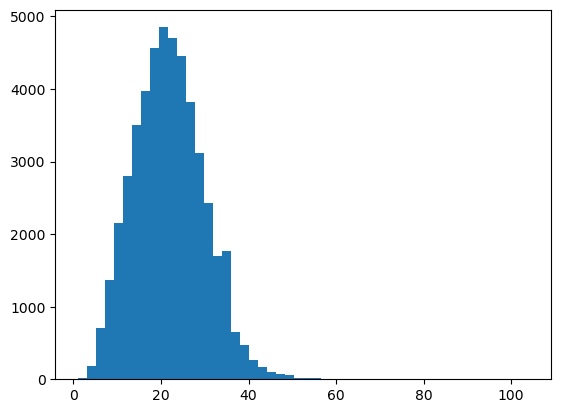

In [50]:
import matplotlib.pyplot as plt

plt.hist([len(sen) for sen in sentences], bins=50)
plt.show()

In [40]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [52]:
MAX_LEN = 128

x = pad_sequences(x, maxlen=MAX_LEN, padding='post')
y = pad_sequences(y, maxlen=MAX_LEN, padding='post')

In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8)

### LSTM Model

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed

In [65]:
model = Sequential()

model.add(Embedding(
    input_dim=len(tokenizer.word_index)+1,
    output_dim=64
))

model.add(LSTM(64, return_sequences=True))

model.add(TimeDistributed(Dense(
    len(tag_tokenizer.word_index)+1,
    activation='softmax'
)))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

2026-02-25 10:32:02.827568: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [63]:
len(tokenizer.word_index)+1    ### count of the unique word 

31818

In [67]:
model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=5
)

Epoch 1/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.9066 - loss: 0.4632
Epoch 2/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - accuracy: 0.9922 - loss: 0.0293
Epoch 3/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 57s 47ms/step - accuracy: 0.9944 - loss: 0.0174
Epoch 4/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 56s 47ms/step - accuracy: 0.9953 - loss: 0.0136
Epoch 5/5
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 57s 47ms/step - accuracy: 0.9960 - loss: 0.0113


In [69]:
loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc)

300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9933 - loss: 0.0207
Accuracy: 0.993410050868988


In [73]:
sentence = sentences[0]

seq = pad_sequences(tokenizer.texts_to_sequences([sentence]), maxlen=MAX_LEN, padding='post')

pred = np.argmax(model.predict(seq), axis=-1)[0]

index_to_tag = {v:k for k,v in tag_tokenizer.word_index.items()}

for w, p in zip(sentence, pred):
    print(w, "->", index_to_tag.get(p))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
Thousands -> nns
of -> in
demonstrators -> nns
have -> vbp
marched -> vbn
through -> in
London -> nnp
to -> to
protest -> vb
the -> dt
war -> nn
in -> in
Iraq -> nnp
and -> cc
demand -> nn
the -> dt
withdrawal -> nn
of -> in
British -> jj
troops -> nns
from -> in
that -> dt
country -> nn
. -> .
